# DS14: Dungeness Crab Cohort Biomass, US Pacific Coast, USA

The Dungeness crab (Metacarcinus magister ) supports one of the most valuable commercial fisheries
on the US Pacific Coast, USA. Stock assessment biologists track annual cohort biomass (metric
tons) at the point of recruitment. A cohort is the group of crabs born in the same year; cohort
biomass is the total mass of that group as it enters the harvestable population. Cohort biomass
grows from a small initial value toward an equilibrium set by habitat and food availability. The
cohort biomass at t = 0 is approximately 138 metric tons.
QOI: Cohort biomass Nt (metric tons) in time step t, where t = 0, 1, 2, . . . denotes the year index.
Fit: r (dimensionless) and K (metric tons).

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset without the saved index becoming a normal column
data = pd.read_csv('DS14.csv', index_col=0)
data.head()


,cohort_biomass_mt
year,
0,138.0
1,246.0
2,528.0
3,940.0
4,913.0


In [ ]:
# Turning the dataset into a numpy array for cohort biomass since the years are linearly spaced
N = data["cohort_biomass_mt"].to_numpy(dtype=float)

Discrete Logistic Model
$ N[t+1] = N[t] * (1 + r * (1 - N[t]/K)) $

r = 0.3915, K = 8.66


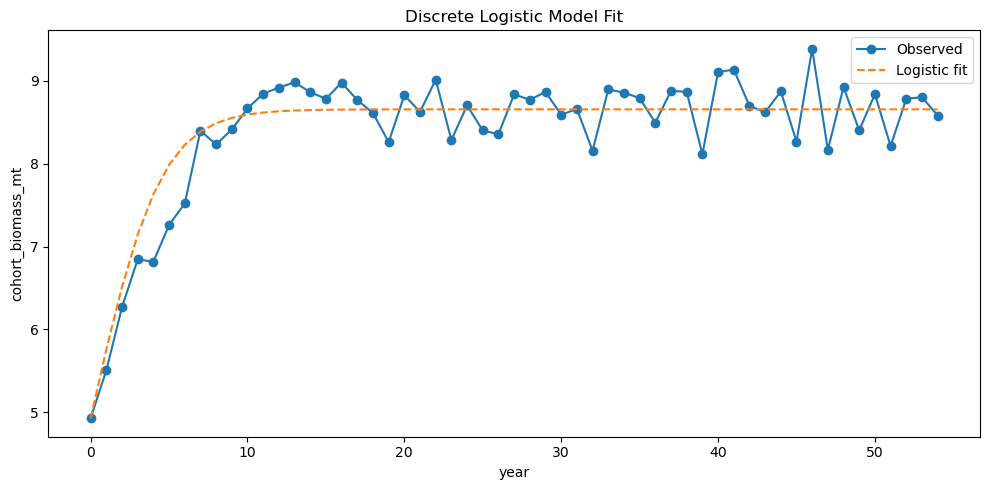

In [20]:
# Estimate r and K from g_t = N[t+1]/N[t] - 1 = r - (r/K)N[t]
slope, r = np.polyfit(N[:-1], N[1:] / N[:-1] - 1, 1)
K = -r / slope

# Simulate discrete logistic model
N_fit = [N[0]]
for i in range(len(N) - 1):
    N_fit.append(N_fit[-1] * (1 + r * (1 - N_fit[-1] / K)))

print(f"r = {r:.4f}, K = {K:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_fit, "--", label="Logistic fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Discrete Logistic Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

Smith-Slatkin Discrete: $N[t]= N[t] * e^r \ 1 + (e^r-1) * N[t] / K$

Smith-Slatkin r = 0.6379, K = 5412.44


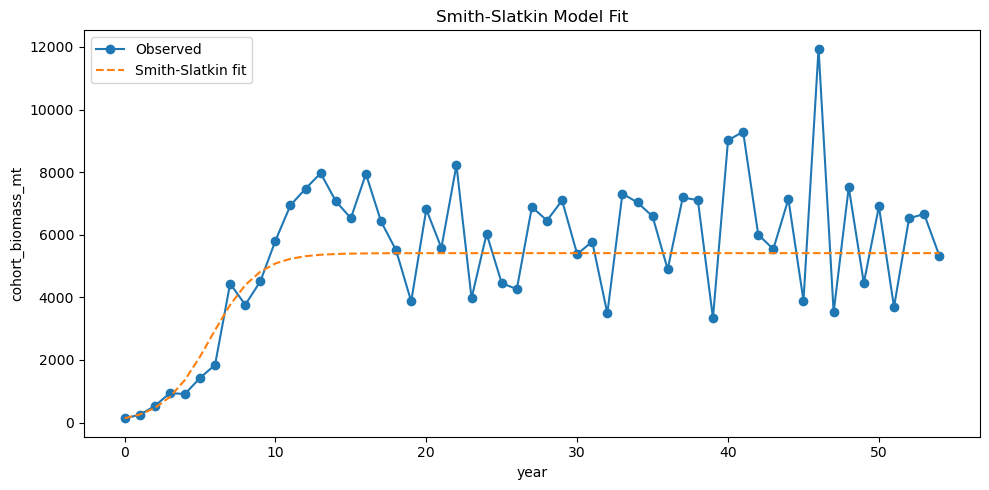

In [33]:

# Linearization: 1/N[t+1] = (1/R)(1/N[t]) + (R-1)/(R K), where R = e^r
a, b = np.polyfit(1 / N[:-1], 1 / N[1:], 1)
R = 1 / a
r_ss = np.log(R)
K_ss = (R - 1) / (R * b)

N_ss = [N[0]]
for i in range(len(N) - 1):
    prev = N_ss[-1]
    N_ss.append((prev * R) / (1 + (R - 1) * prev / K_ss))

print(f"Smith-Slatkin r = {r_ss:.4f}, K = {K_ss:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_ss, "--", label="Smith-Slatkin fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Smith-Slatkin Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
#Discrete Beverton Holt model

Beverton-Holt lambda = 4.9688, alpha = 0.000769


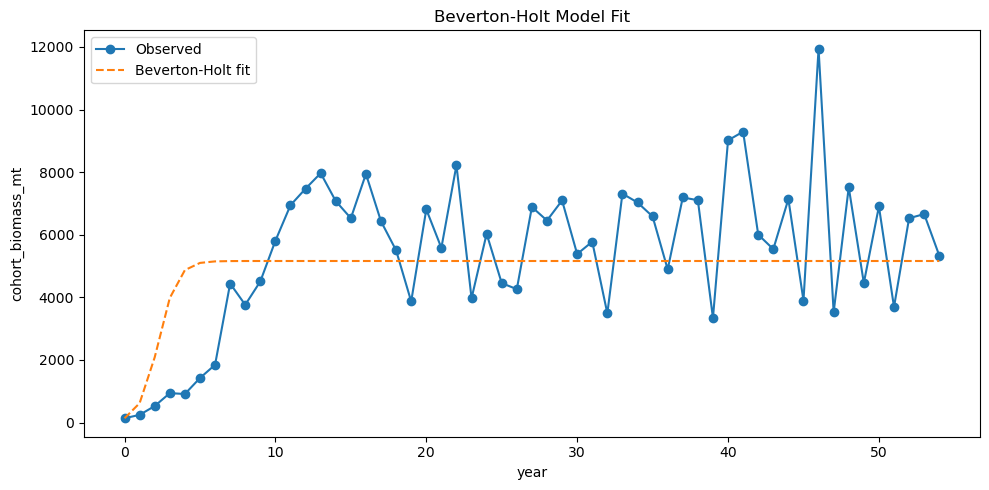

In [30]:
# Beverton-Holt: N[t+1] = (lambda * N[t]) / (1 + alpha * N[t])
N = data["cohort_biomass_mt"].to_numpy(dtype=float)
# N = np.log(N)

# Using np_polyfit to find out the lambda and alpha params

m, c = np.polyfit(N[:-1], N[:-1] / N[1:], 1)
lam = 1 / c
alpha = m * lam

N_bh = [N[0]]
for i in range(len(N) - 1):
    prev = N_bh[-1]
    N_bh.append((lam * prev) / (1 + alpha * prev))

print(f"Beverton-Holt lambda = {lam:.4f}, alpha = {alpha:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_bh, "--", label="Beverton-Holt fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Beverton-Holt Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

Ricker r = 0.8469, K = 5922.71


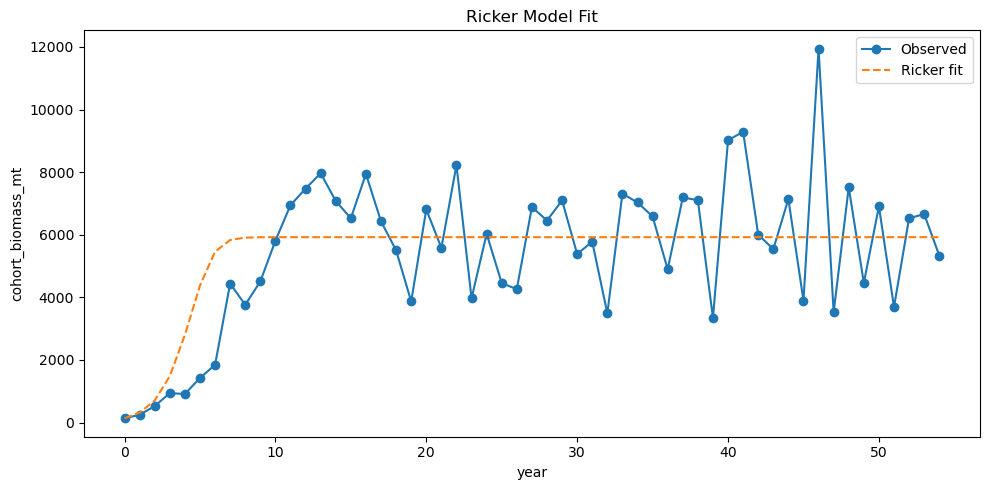

Theta-Ricker (theta=0.7) r = 0.9996, K = 5776.99


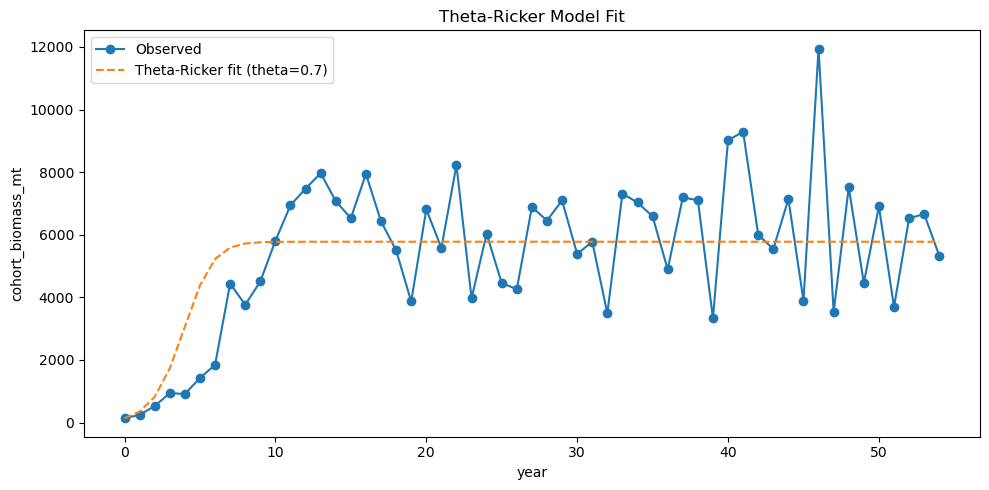

In [31]:
# Ricker and Theta-Ricker fits

# Use only positive transitions for log-ratio linearization
mask = (N[:-1] > 0) & (N[1:] > 0)
N_t = N[:-1][mask]
N_t1 = N[1:][mask]
log_ratio = np.log(N_t1 / N_t)

# 4) Ricker: N[t+1] = N[t] * exp(r * (1 - N[t]/K))
# Linear form: log(N[t+1]/N[t]) = r - (r/K) * N[t]
slope_r, r_ricker = np.polyfit(N_t, log_ratio, 1)
K_ricker = -r_ricker / slope_r

N_ricker = [N[0]]
for i in range(len(N) - 1):
    prev = N_ricker[-1]
    N_ricker.append(prev * np.exp(r_ricker * (1 - prev / K_ricker)))

print(f"Ricker r = {r_ricker:.4f}, K = {K_ricker:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_ricker, "--", label="Ricker fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Ricker Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Theta-Ricker with theta fixed at 0.7:
# N[t+1] = N[t] * exp(r * (1 - (N[t]/K)^theta))
# Linear form: log(N[t+1]/N[t]) = r - (r/K^theta) * N[t]^theta
theta = 0.7
X_theta = N_t ** theta
slope_th, r_theta = np.polyfit(X_theta, log_ratio, 1)
K_theta = (-r_theta / slope_th) ** (1 / theta)

N_theta = [N[0]]
for i in range(len(N) - 1):
    prev = N_theta[-1]
    N_theta.append(prev * np.exp(r_theta * (1 - (prev / K_theta) ** theta)))

print(f"Theta-Ricker (theta={theta}) r = {r_theta:.4f}, K = {K_theta:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_theta, "--", label=f"Theta-Ricker fit (theta={theta})")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Theta-Ricker Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

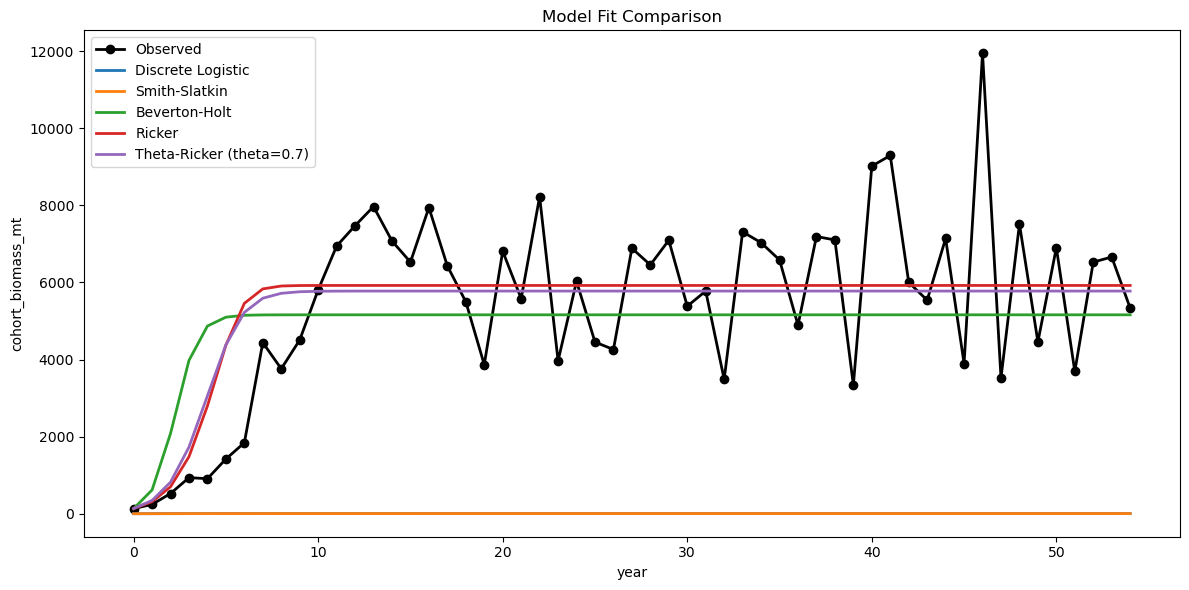

Model ranking (best to worst by RMSE):
                   Model      RMSE       MAE     AICc      BIC
                  Ricker 1762.4972 1385.2849 826.4243 830.2082
Theta-Ricker (theta=0.7) 1778.8227 1407.6238 827.4385 831.2224
           Beverton-Holt 2086.1443 1693.1751 844.9688 848.7527
       Discrete Logistic 5941.4134 5438.8724 960.0980 963.8819
           Smith-Slatkin 5941.4474 5438.9237 960.0987 963.8826

Best model by AICc: Ricker
Best model by BIC: Ricker


In [32]:
# Compare all model fits on one plot and rank model performance
models = {
    "Discrete Logistic": np.asarray(N_fit, dtype=float),
    "Smith-Slatkin": np.asarray(N_ss, dtype=float),
    "Beverton-Holt": np.asarray(N_bh, dtype=float),
    "Ricker": np.asarray(N_ricker, dtype=float),
    "Theta-Ricker (theta=0.7)": np.asarray(N_theta, dtype=float),
}

# Number of fitted parameters for each model
a_param_count = {
    "Discrete Logistic": 2,
    "Smith-Slatkin": 2,
    "Beverton-Holt": 2,
    "Ricker": 2,
    "Theta-Ricker (theta=0.7)": 2,  # theta fixed, so only r and K are fitted
}

# Overlay all fits with observed data
plt.figure(figsize=(12, 6))
plt.plot(data.index, N, "o-", color="black", linewidth=2, label="Observed")

for name, series in models.items():
    plt.plot(data.index, series, linewidth=2, label=name)

plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Model Fit Comparison")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Compute error metrics + information criteria
n = len(N)
rows = []

for name, series in models.items():
    residual = np.asarray(N, dtype=float) - series
    rss = float(np.sum(residual ** 2))
    rss = max(rss, 1e-12)

    rmse = np.sqrt(np.mean(residual ** 2))
    mae = np.mean(np.abs(residual))

    k = a_param_count[name]
    aic = n * np.log(rss / n) + 2 * k
    aicc = aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf
    bic = n * np.log(rss / n) + k * np.log(n)

    rows.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "AICc": aicc,
        "BIC": bic,
    })

metrics = pd.DataFrame(rows)

print("Model ranking (best to worst by RMSE):")
print(
    metrics.sort_values("RMSE").to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

best_aicc_model = metrics.sort_values("AICc").iloc[0]["Model"]
best_bic_model = metrics.sort_values("BIC").iloc[0]["Model"]

print(f"\nBest model by AICc: {best_aicc_model}")
print(f"Best model by BIC: {best_bic_model}")